# Synthetic experiment results



## Setup


In [1]:
from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True

try:
    import seaborn as sns
    sns.set_context('talk')
except Exception:
    sns = None


def place_legend(ax, outside: bool = True, ncol: int = 1) -> None:
    fig = ax.figure
    if not outside:
        ax.legend(ncol=ncol)
        return
    if not getattr(fig, '_legend_widened', False):
        w, h = fig.get_size_inches()
        fig.set_size_inches(w * 1.35, h, forward=True)
        fig._legend_widened = True
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        ncol=ncol,
    )


In [2]:
import sys

def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in (start, *start.parents):
        if (p / 'pyproject.toml').exists():
            return p
    return start


REPO_ROOT = _find_repo_root(Path.cwd())

for p in (REPO_ROOT, REPO_ROOT / 'src'):
    ps = str(p)
    if ps not in sys.path:
        sys.path.append(ps)

REPO_ROOT


PosixPath('.')

In [3]:
RESULTS_BASE = REPO_ROOT / 'results'
RUN_DIRS = {
    'Active': RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed42',
    'Uniform': RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_uniform_w2_matern5_2_seed42',
    'Random': RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_random_w2_matern5_2_seed42',
}

RUN_DIRS = {k: v for k, v in RUN_DIRS.items() if v.exists()}
if not RUN_DIRS:
    raise FileNotFoundError('No valid RUN_DIRS found. Update RUN_DIRS paths.')
RUN_DIRS


{'Active': PosixPath('results/synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed42'),
 'Uniform': PosixPath('results/synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_uniform_w2_matern5_2_seed42'),
 'Random': PosixPath('results/synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_random_w2_matern5_2_seed42')}

In [4]:
@dataclass
class RunArtifacts:
    run_dir: Path
    metrics: dict | None
    errors: pd.DataFrame | None
    errors_common: pd.DataFrame | None
    errors_by_step: pd.DataFrame | None
    errors_common_by_step: pd.DataFrame | None
    spline_errors: pd.DataFrame | None
    spline_errors_by_step: pd.DataFrame | None
    metrics_by_step: pd.DataFrame | None
    acquisition: dict | None
    metadata: dict | None
    shared_manifest: dict | None


def _read_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    return json.loads(path.read_text())


def _read_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    return pd.read_csv(path)


def load_run(run_dir: Path) -> RunArtifacts:
    metrics = _read_json(run_dir / 'metrics.json')
    if metrics is not None and 'metrics' in metrics:
        metrics = metrics['metrics']
    errors = _read_csv(run_dir / 'errors.csv')
    errors_common = _read_csv(run_dir / 'errors_common_reference.csv')
    errors_by_step = _read_csv(run_dir / 'errors_by_step.csv')
    errors_common_by_step = _read_csv(run_dir / 'errors_common_reference_by_step.csv')
    spline_errors = _read_csv(run_dir / 'spline_errors.csv')
    spline_errors_by_step = _read_csv(run_dir / 'spline_errors_by_step.csv')
    metrics_by_step = _read_csv(run_dir / 'metrics_by_step.csv')
    acquisition = _read_json(run_dir / 'acquisition_artifacts.json')
    metadata = _read_json(run_dir / 'metadata.json')
    shared_manifest = _read_json(run_dir / 'shared_artifacts' / 'manifest.json')
    return RunArtifacts(
        run_dir=run_dir,
        metrics=metrics,
        errors=errors,
        errors_common=errors_common,
        errors_by_step=errors_by_step,
        errors_common_by_step=errors_common_by_step,
        spline_errors=spline_errors,
        spline_errors_by_step=spline_errors_by_step,
        metrics_by_step=metrics_by_step,
        acquisition=acquisition,
        metadata=metadata,
        shared_manifest=shared_manifest,
    )


RUNS = {label: load_run(path) for label, path in RUN_DIRS.items()}
RUN_PRIMARY = next(iter(RUNS.values())) if RUNS else None


In [5]:

def parse_strategy(strategy: str) -> dict[str, str]:
    parts = strategy.split(':') if isinstance(strategy, str) else []
    base = parts[0] if parts else 'unknown'
    if base == 'active':
        acquisition = parts[1] if len(parts) > 1 else 'unknown'
        warp = parts[2] if len(parts) > 2 else 'unknown'
        kernel = parts[-1] if len(parts) > 3 else 'unknown'
    else:
        acquisition = base
        warp = parts[1] if len(parts) > 1 else 'unknown'
        kernel = parts[-1] if len(parts) > 2 else 'unknown'
    return {
        'base': base,
        'acquisition': acquisition,
        'warp': warp,
        'kernel': kernel,
    }


def add_strategy_columns(df: pd.DataFrame | None) -> pd.DataFrame | None:
    if df is None or df.empty or 'strategy' not in df.columns:
        return df
    parsed = df['strategy'].apply(parse_strategy)
    parsed_df = pd.DataFrame(parsed.tolist(), index=df.index)
    out = df.copy()
    for col in ['base', 'acquisition', 'warp', 'kernel']:
        out[col] = parsed_df[col]
    return out


def _concat_frames(attr_name: str) -> pd.DataFrame | None:
    frames = []
    for label, run in RUNS.items():
        df = getattr(run, attr_name)
        if df is None or df.empty:
            continue
        df = df.copy()
        if 'strategy' not in df.columns:
            if run.metrics:
                df['strategy'] = list(run.metrics.keys())[0]
            else:
                df['strategy'] = label
        df['run_label'] = label
        df['run_dir'] = str(run.run_dir)
        frames.append(df)
    if frames:
        return pd.concat(frames, ignore_index=True)
    return None


def _metrics_frame() -> pd.DataFrame | None:
    rows = []
    for label, run in RUNS.items():
        if not run.metrics:
            continue
        for strategy, payload in run.metrics.items():
            row = {'strategy': strategy}
            row.update(payload or {})
            row['run_label'] = label
            row['run_dir'] = str(run.run_dir)
            rows.append(row)
    if rows:
        return pd.DataFrame(rows)
    return None


def _merge_acquisition() -> dict | None:
    merged = {}
    for _, run in RUNS.items():
        if run.acquisition:
            for strategy, payload in run.acquisition.items():
                merged[strategy] = payload
    return merged or None


STRATEGY_TO_RUN_DIR = {}
for _, run in RUNS.items():
    strategies = []
    if run.metrics:
        strategies.extend(list(run.metrics.keys()))
    if run.acquisition:
        strategies.extend(list(run.acquisition.keys()))
    if run.metrics_by_step is not None and 'strategy' in run.metrics_by_step.columns:
        strategies.extend(list(run.metrics_by_step['strategy'].unique()))
    for strat in strategies:
        STRATEGY_TO_RUN_DIR.setdefault(strat, run.run_dir)

METRICS_FINAL = _metrics_frame()
METRICS_STEP = add_strategy_columns(_concat_frames('metrics_by_step'))
ERRORS_STEP = add_strategy_columns(_concat_frames('errors_by_step'))
ERRORS_FINAL = add_strategy_columns(_concat_frames('errors'))
ACQUISITION = _merge_acquisition()


## Active vs. Uniform vs. Random


Saved to figures/branching.pdf


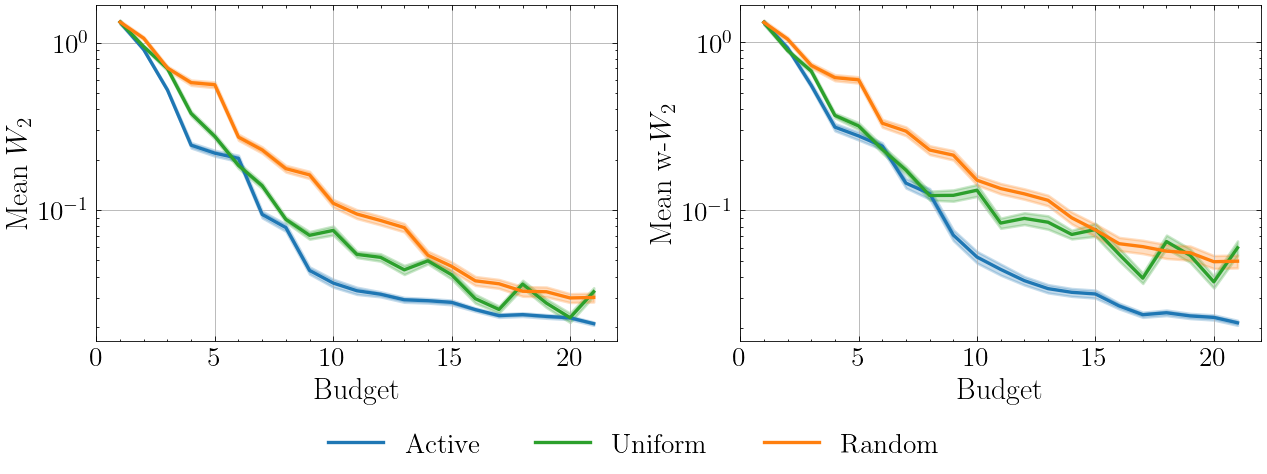

In [6]:
import scienceplots
from matplotlib.lines import Line2D
plt.style.use(['science'])

MAX_STEP = 20

RESULTS_BASE = REPO_ROOT / 'results'
COMPARISON_RUN_DIRS = {
    'Active': [
        (42, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed42'),
        (43, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed43'),
        (44, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed44'),
        (45, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed45'),
        (46, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed46'),
    ],
    'Uniform': [
        (42, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_uniform_w2_matern5_2_seed42'),
        (43, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_uniform_w2_matern5_2_seed43'),
        (44, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_uniform_w2_matern5_2_seed44'),
        (45, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_uniform_w2_matern5_2_seed45'),
        (46, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_uniform_w2_matern5_2_seed46'),
    ],
    'Random': [
        (42, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_random_w2_matern5_2_seed42'),
        (43, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_random_w2_matern5_2_seed43'),
        (44, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_random_w2_matern5_2_seed44'),
        (45, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_random_w2_matern5_2_seed45'),
        (46, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_random_w2_matern5_2_seed46'),
    ],
}

PREFIX_BY_LABEL = {
    'Active': 'active:',
    'Uniform': 'uniform:',
    'Random': 'random:',
}


def _velocity_weights(run_dir: Path) -> pd.DataFrame | None:
    rec_dir = run_dir / 'reconstruction'
    candidates = sorted([p for p in rec_dir.iterdir() if p.is_dir()]) if rec_dir.exists() else []
    vel_dir = candidates[0] if candidates else None
    if vel_dir is None:
        return None

    times_path = vel_dir / 'wasserstein_velocity_grid_times.npy'
    vel_path = vel_dir / 'wasserstein_velocities_grid.npy'
    if not (times_path.exists() and vel_path.exists()):
        return None

    vel_times = np.asarray(np.load(times_path), dtype=float)
    velocities = np.asarray(np.load(vel_path), dtype=float)
    if velocities.size == vel_times.size - 1:
        times = vel_times[:-1]
    elif velocities.size == vel_times.size:
        times = vel_times
    else:
        return None

    vel_sum = float(np.sum(velocities))
    weights = velocities / vel_sum if vel_sum > 0 else np.zeros_like(velocities)
    return pd.DataFrame({'time': times, 'velocity_weight': weights})


def _load_errors(run_dir: Path, label: str, seed: int) -> pd.DataFrame | None:
    errors_path = run_dir / 'errors_by_step.csv'
    if not errors_path.exists():
        print(f'Missing errors_by_step.csv: {errors_path}')
        return None
    df = pd.read_csv(errors_path)
    if df.empty:
        return df

    prefix = PREFIX_BY_LABEL[label]
    if 'strategy' in df.columns:
        df = df[df['strategy'].astype(str).str.startswith(prefix)].copy()
    if df.empty:
        print(f'No {label} strategy in {errors_path}')
        return None

    if 'velocity_weighted_error' in df.columns:
        df['velocity_weighted_error_norm'] = df['velocity_weighted_error']
    else:
        weights_df = _velocity_weights(run_dir)
        if weights_df is not None:
            df = df.copy()
            df['time_key'] = df['time'].round(8)
            weights_df = weights_df.copy()
            weights_df['time_key'] = weights_df['time'].round(8)
            df = df.merge(weights_df[['time_key', 'velocity_weight']], on='time_key', how='left')
            df['velocity_weighted_error_norm'] = df['error'] * df['velocity_weight']
            df = df.drop(columns=['time_key', 'velocity_weight'])
        else:
            df['velocity_weighted_error_norm'] = np.nan

    df = df[df['step'] <= MAX_STEP].copy()
    df['run_label'] = label
    df['seed'] = seed
    df['run_dir'] = str(run_dir)
    return df


def _collect_errors_by_step() -> pd.DataFrame | None:
    frames = []
    for label, seed_run_dirs in COMPARISON_RUN_DIRS.items():
        for seed, run_dir in seed_run_dirs:
            df = _load_errors(run_dir, label, seed)
            if df is None or df.empty:
                continue
            frames.append(df)
    if frames:
        return pd.concat(frames, ignore_index=True)
    return None


def _summary_sem(frame: pd.DataFrame, metric: str, agg: str = 'mean') -> pd.DataFrame:
    frame = frame.dropna(subset=[metric]).copy()
    if agg == 'sum':
        seed_cols = [col for col in ('seed', 'run_dir') if col in frame.columns]
        if seed_cols:
            per_seed = frame.groupby(seed_cols + ['step'], as_index=False)[metric].sum()
            center = per_seed.groupby('step')[metric].mean()
            row_grp = frame.groupby('step')[metric]
            row_std = row_grp.std().fillna(0.0)
            row_n = row_grp.count().clip(lower=1)
            n_seeds = per_seed.groupby('step')[metric].count().clip(lower=1)
            sem = row_std * np.sqrt(row_n) / n_seeds
        else:
            grp = frame.groupby('step')[metric]
            center = grp.sum()
            sem = grp.std().fillna(0.0) * np.sqrt(grp.count().clip(lower=1))
    else:
        grp = frame.groupby('step')[metric]
        center = grp.mean()
        sem = grp.std().fillna(0.0) / np.sqrt(grp.count().clip(lower=1))
    z = 1.644854
    lo = center - z * sem
    hi = center + z * sem
    out = pd.DataFrame({'step': center.index, 'mean': center.values, 'lo': lo.values, 'hi': hi.values})
    return out.sort_values('step')


df = _collect_errors_by_step()
if df is None or df.empty:
    if ERRORS_STEP is None or ERRORS_STEP.empty:
        print('No errors_by_step.csv found')
        df = None
    else:
        print('No multi-seed errors_by_step.csv found; falling back to loaded runs')
        df = ERRORS_STEP.copy()
        if 'velocity_weighted_error_norm' not in df.columns:
            df['velocity_weighted_error_norm'] = df.get('velocity_weighted_error', np.nan)

if df is not None and not df.empty:
    df = df[df['step'] <= MAX_STEP].copy()
    required = {'strategy', 'step', 'time', 'error', 'velocity_weighted_error_norm'}
    missing = required.difference(df.columns)
    if missing:
        print(f'Missing columns: {sorted(missing)}')
    else:
        selections = {
            label: df['strategy'].astype(str).str.startswith(prefix)
            for label, prefix in PREFIX_BY_LABEL.items()
        }

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
        colors = {'Active': '#1f77b4', 'Uniform': '#2ca02c', 'Random': '#ff7f0e'}

        for label, mask in selections.items():
            sub = df[mask].copy()
            if sub.empty:
                print(f'No data for {label}')
                continue

            stats_left = _summary_sem(sub, 'error', agg='mean')
            stats_right = _summary_sem(sub, 'velocity_weighted_error_norm', agg='sum')

            color = colors.get(label, None)
            axes[0].plot(stats_left['step'] + 1, stats_left['mean'], label=label, color=color, linewidth=2)
            axes[0].fill_between(stats_left['step'] + 1, stats_left['lo'], stats_left['hi'], color=color, alpha=0.25)
            axes[1].plot(stats_right['step'] + 1, stats_right['mean'], label=label, color=color, linewidth=2)
            axes[1].fill_between(stats_right['step'] + 1, stats_right['lo'], stats_right['hi'], color=color, alpha=0.25)

        for ax in axes:
            ax.set_xlabel('Budget')
            ax.set_yscale('log')

        axes[0].set_ylabel('Mean $W_2$')
        axes[1].set_ylabel('Mean w-$W_2$')

        legend_handles = [
            Line2D([], [], color=colors[label], linewidth=2, label=label)
            for label in selections.keys()
        ]
        fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
                   ncol=3, frameon=False)
        plt.tight_layout(rect=[0, 0.08, 1, 1])

        fig.savefig(REPO_ROOT / 'figures' / 'branching.pdf', bbox_inches='tight', dpi=300)
        print(f"Saved to {REPO_ROOT / 'figures' / 'branching.pdf'}")

        plt.show()


## Ablations


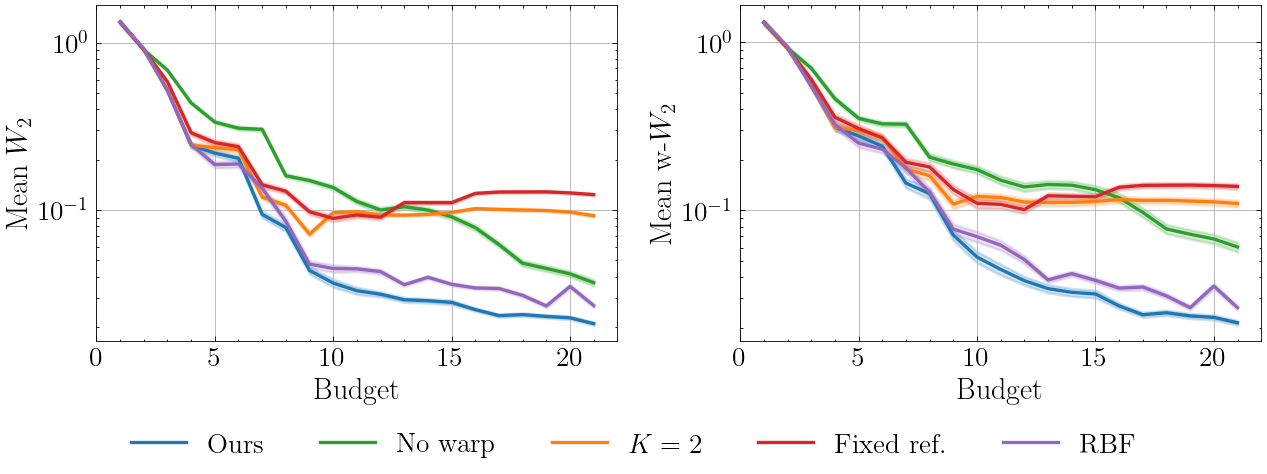

In [7]:
import scienceplots
from matplotlib.lines import Line2D
plt.style.use(['science'])

RESULTS_BASE = REPO_ROOT / 'results'


def _latest_synthetic_run(pattern: str) -> Path | None:
    matches = sorted(
        RESULTS_BASE.glob(pattern),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    for candidate in matches:
        if (candidate / 'errors_by_step.csv').exists():
            return candidate
    return None


def _available_seed_runs(pattern_template: str, seeds: list[int]) -> list[tuple[int, Path]]:
    runs = []
    for seed in seeds:
        run_dir = _latest_synthetic_run(pattern_template.format(seed=seed))
        if run_dir is not None:
            runs.append((seed, run_dir))
    return runs


LABEL_ORDER = ['Ours', 'No warp', '$K=2$', 'Fixed ref.', 'RBF']
COLORS = {
    'Ours': '#1f77b4',
    'No warp': '#2ca02c',
    '$K=2$': '#ff7f0e',
    'Fixed ref.': '#d62728',
    'RBF': '#9467bd',
}

ABLATION_RUN_DIRS = {
    'Ours': [
        (42, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed42'),
        (43, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed43'),
        (44, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed44'),
        (45, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed45'),
        (46, RESULTS_BASE / 'synthetic_2026-05-25_23-52-03_oscillatory_sequential_branching_active_w2_matern5_2_variance_seed46'),
    ],
    'No warp': _available_seed_runs('synthetic_*_oscillatory_sequential_branching_no_warp_seed{seed}', [42, 43, 44, 45, 46]),
    '$K=2$': _available_seed_runs('synthetic_*_oscillatory_sequential_branching_basis2_seed{seed}', [42, 43, 44, 45, 46]),
    'Fixed ref.': _available_seed_runs('synthetic_*_oscillatory_sequential_branching_fixed_ref_seed{seed}', [42, 43, 44, 45, 46]),
    'RBF': _available_seed_runs('synthetic_*_oscillatory_sequential_branching_rbf_seed{seed}', [42, 43, 44, 45, 46]),
}
MISSING_ABLATION_LABELS = [label for label in LABEL_ORDER if not ABLATION_RUN_DIRS.get(label)]
if MISSING_ABLATION_LABELS:
    print('Missing complete synthetic ablation runs for: ' + ', '.join(MISSING_ABLATION_LABELS))

USE_ERROR_BANDS = True
MAX_STEP = 20


def _velocity_weights_any(run_dir: Path) -> pd.DataFrame | None:
    rec_dir = run_dir / 'reconstruction'
    if not rec_dir.exists():
        return None
    candidates = sorted([p for p in rec_dir.iterdir() if p.is_dir()])
    vel_dir = candidates[0] if candidates else None
    if vel_dir is None:
        return None

    times_path = vel_dir / 'wasserstein_velocity_grid_times.npy'
    vel_path = vel_dir / 'wasserstein_velocities_grid.npy'
    if not (times_path.exists() and vel_path.exists()):
        return None

    vel_times = np.asarray(np.load(times_path), dtype=float)
    velocities = np.asarray(np.load(vel_path), dtype=float)
    if velocities.size == vel_times.size - 1:
        times = vel_times[:-1]
    elif velocities.size == vel_times.size:
        times = vel_times
    else:
        return None

    vel_sum = float(np.sum(velocities))
    weights = velocities / vel_sum if vel_sum > 0 else np.zeros_like(velocities)
    return pd.DataFrame({'time': times, 'velocity_weight': weights})


def _load_ablation_errors(run_dir: Path, label: str, seed: int) -> pd.DataFrame | None:
    errors_path = run_dir / 'errors_by_step.csv'
    if not errors_path.exists():
        print(f'Missing errors_by_step.csv: {errors_path}')
        return None
    df = pd.read_csv(errors_path)
    if df.empty:
        return df
    if 'strategy' in df.columns:
        s = df['strategy'].astype(str)
        mask = s.str.startswith('active:')
        if mask.any():
            df = df[mask]
    if 'velocity_weighted_error' in df.columns:
        df['velocity_weighted_error_norm'] = df['velocity_weighted_error']
    else:
        weights_df = _velocity_weights_any(run_dir)
        if weights_df is not None:
            df = df.copy()
            df['time_key'] = df['time'].round(8)
            weights_df = weights_df.copy()
            weights_df['time_key'] = weights_df['time'].round(8)
            df = df.merge(weights_df[['time_key', 'velocity_weight']], on='time_key', how='left')
            df['velocity_weighted_error_norm'] = df['error'] * df['velocity_weight']
            df = df.drop(columns=['time_key', 'velocity_weight'])
        else:
            df['velocity_weighted_error_norm'] = np.nan
    df = df[df['step'] <= MAX_STEP].copy()
    df['variant'] = label
    df['seed'] = seed
    df['run_dir'] = str(run_dir)
    return df


def _collect_ablation_errors_by_step() -> pd.DataFrame | None:
    frames = []
    for label, seed_run_dirs in ABLATION_RUN_DIRS.items():
        for seed, run_dir in seed_run_dirs:
            df = _load_ablation_errors(run_dir, label, seed)
            if df is None or df.empty:
                continue
            frames.append(df)
    if frames:
        return pd.concat(frames, ignore_index=True)
    return None


def _summary_sem(frame: pd.DataFrame, metric: str, agg: str = 'mean') -> pd.DataFrame:
    frame = frame.dropna(subset=[metric]).copy()
    if agg == 'sum':
        seed_cols = [col for col in ('seed', 'run_dir') if col in frame.columns]
        if seed_cols:
            per_seed = frame.groupby(seed_cols + ['step'], as_index=False)[metric].sum()
            center = per_seed.groupby('step')[metric].mean()
            row_grp = frame.groupby('step')[metric]
            row_std = row_grp.std().fillna(0.0)
            row_n = row_grp.count().clip(lower=1)
            n_seeds = per_seed.groupby('step')[metric].count().clip(lower=1)
            sem = row_std * np.sqrt(row_n) / n_seeds
        else:
            grp = frame.groupby('step')[metric]
            center = grp.sum()
            sem = grp.std().fillna(0.0) * np.sqrt(grp.count().clip(lower=1))
    else:
        grp = frame.groupby('step')[metric]
        center = grp.mean()
        sem = grp.std().fillna(0.0) / np.sqrt(grp.count().clip(lower=1))
    z = 1.644854
    lo = center - z * sem
    hi = center + z * sem
    out = pd.DataFrame({'step': center.index, 'mean': center.values, 'lo': lo.values, 'hi': hi.values})
    return out.sort_values('step')


abl_df = _collect_ablation_errors_by_step()
if abl_df is None or abl_df.empty:
    print('No ablation errors_by_step.csv found')
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

    for label in [label for label in LABEL_ORDER if ABLATION_RUN_DIRS.get(label)]:
        sub = abl_df[abl_df['variant'] == label]
        if sub.empty:
            print(f'No data for {label}')
            continue
        stats_left = _summary_sem(sub, 'error', agg='mean')
        stats_right = _summary_sem(sub, 'velocity_weighted_error_norm', agg='sum')

        color = COLORS.get(label, None)
        axes[0].plot(stats_left['step'] + 1, stats_left['mean'], label=label, color=color, linewidth=2)
        if USE_ERROR_BANDS:
            axes[0].fill_between(stats_left['step'] + 1, stats_left['lo'], stats_left['hi'], color=color, alpha=0.2)
        axes[1].plot(stats_right['step'] + 1, stats_right['mean'], label=label, color=color, linewidth=2)
        if USE_ERROR_BANDS:
            axes[1].fill_between(stats_right['step'] + 1, stats_right['lo'], stats_right['hi'], color=color, alpha=0.2)

    for ax in axes:
        ax.set_xlabel('Budget')
        ax.set_yscale('log')

    axes[0].set_ylabel('Mean $W_2$')
    axes[1].set_ylabel('Mean w-$W_2$')

    legend_handles = [
        Line2D([], [], color=COLORS[lbl], linewidth=2, label=lbl)
        for lbl in LABEL_ORDER
        if lbl in COLORS and ABLATION_RUN_DIRS.get(lbl)
    ]
    fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
               ncol=5, frameon=False)
    plt.tight_layout(rect=[0, 0.08, 1, 1])

    plt.savefig(REPO_ROOT / 'figures' / 'branching_ablation.pdf', bbox_inches='tight', dpi=300)
    plt.show()


## Acquisition Visualization Data


In [8]:
if RUN_PRIMARY is None:
    print('No runs loaded')
else:
    shared_dir = RUN_PRIMARY.run_dir / 'shared_artifacts'

    candidate_pool = None
    if (shared_dir / 'candidate_pool.npy').exists():
        candidate_pool = np.load(shared_dir / 'candidate_pool.npy')

    eval_times = None
    if (shared_dir / 'eval_times.npy').exists():
        eval_times = np.load(shared_dir / 'eval_times.npy')

    eval_velocities = None
    if (shared_dir / 'eval_velocities.npy').exists():
        eval_velocities = np.load(shared_dir / 'eval_velocities.npy')

    print('candidate_pool:', None if candidate_pool is None else candidate_pool.shape)
    print('eval_times:', None if eval_times is None else eval_times.shape)
    print('eval_velocities:', None if eval_velocities is None else eval_velocities.shape)


candidate_pool: (50,)
eval_times: (500,)
eval_velocities: (499,)


## Acquisition Visualization


Available checkpoints: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]


.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved to figures/viz_acquisitions.pdf


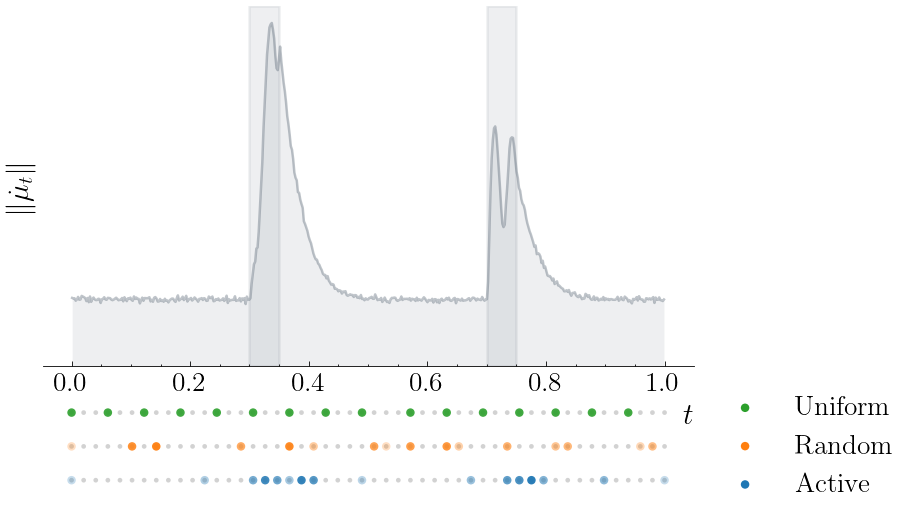

In [9]:

CHECKPOINT = 15

import pickle
import warnings
from matplotlib import colors as mcolors

def load_checkpoint_observed_times(run_dir: Path, strategy: str, step: int) -> np.ndarray | None:
    'Load observed_times from checkpoint state pickle file.'
    strategy_dir_name = strategy.replace('/', '_')
    checkpoint_dir = run_dir / 'checkpoint_state' / strategy_dir_name
    pkl_path = checkpoint_dir / f'step_{step:03d}.pkl'
    if not pkl_path.exists():
        print(f'Debug: Pickle not found at {pkl_path}')
        return None
    try:
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
        obs_times = data.get('observed_times')
        if obs_times is not None:
            return np.asarray(obs_times)
        return None
    except Exception as e:
        print(f'Warning: failed to load {pkl_path}: {e}')
        return None

if ACQUISITION is None:
    print('No acquisition_artifacts.json found')
elif candidate_pool is None:
    print('No candidate_pool.npy found')
else:
    available_steps = None
    if METRICS_STEP is not None and not METRICS_STEP.empty:
        available_steps = sorted(METRICS_STEP['step'].unique())
        print(f'Available checkpoints: {available_steps}')

    def _is_active_strategy(strategy: str) -> bool:
        return str(strategy).startswith('active:')

    def _is_uniform(strategy: str) -> bool:
        return str(strategy).startswith('uniform:')

    def _is_random(strategy: str) -> bool:
        return str(strategy).startswith('random:')

    label_map = {
        'Active': _is_active_strategy,
        'Random': _is_random,
        'Uniform': _is_uniform,
    }

    strategies_sorted = [
        s for s in sorted(ACQUISITION.keys())
        if any(predicate(s) for predicate in label_map.values())
    ]
    if not strategies_sorted:
        print('No matching strategies found')
    else:
        row_spacing = 0.2
        y_map = {s: i * row_spacing for i, s in enumerate(strategies_sorted)}
        n_strategies = len(strategies_sorted)

        strip_ratio = max(0.6, 0.25 * n_strategies)
        fig, (ax_vel, ax_strip) = plt.subplots(
            2,
            1,
            figsize=(7, 5.5),
            gridspec_kw={'height_ratios': [2.0, strip_ratio], 'hspace': 0.05},
        )
        ax_strip.set_facecolor('none')
        ax_strip.patch.set_alpha(0)
        ax_strip.set_zorder(0)
        ax_vel.set_zorder(1)

        if eval_times is None or eval_velocities is None:
            ax_vel.text(
                0.5,
                0.5,
                'eval_times/eval_velocities not found',
                ha='center',
                va='center',
                transform=ax_vel.transAxes,
            )
            ax_vel.set_axis_off()
        else:
            if len(eval_velocities) == len(eval_times):
                x = eval_times
            elif len(eval_velocities) == len(eval_times) - 1:
                x = 0.5 * (eval_times[:-1] + eval_times[1:])
            else:
                x = np.arange(len(eval_velocities))

            vel_color = '#2c3e50'
            ax_vel.fill_between(x, 0, eval_velocities, alpha=0.08, color=vel_color, linewidth=0)
            ax_vel.plot(x, eval_velocities, linewidth=1.5, color=vel_color, alpha = 0.3)
            ax_vel.set_ylabel(r'$\|\dot{\mu}_t\|$')
            ax_vel.set_xlabel('$t$', loc='right')
            ax_vel.tick_params(axis='x', labelbottom=True, bottom=True, top=False, which='both')
            ax_vel.tick_params(axis='y', left=False, right=False, labelleft=False, length=0, which='both')
            ax_vel.set_yticks([])
            ax_vel.xaxis.set_ticks_position('bottom')

            ax_vel.spines['top'].set_visible(False)
            ax_vel.spines['right'].set_visible(False)
            ax_vel.spines['left'].set_visible(False)
            ax_vel.grid(False)
            ax_vel.set_ylim(bottom=0)

            event_intervals = [(0.30, 0.35), (0.70, 0.75)]
            for t_start, t_end in event_intervals:
                ax_vel.axvspan(t_start, t_end, alpha=0.08, color=vel_color, zorder=0)

        title_suffix = f' (checkpoint {CHECKPOINT})' if CHECKPOINT is not None else ' (all checkpoints)'

        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        for s in strategies_sorted:
            y = y_map[s]
            ax_strip.scatter(
                candidate_pool,
                np.full_like(candidate_pool, y, dtype=float),
                s=8,
                alpha=0.5,
                color='0.65',
                edgecolors='none',
                zorder=1,
            )

        labels_used = set()
        alpha_min = 0.25
        alpha_max = 0.95

        def _alpha_from_steps(steps: np.ndarray | None) -> np.ndarray | None:
            if steps is None:
                return None
            steps = np.asarray(steps, dtype=float)
            if steps.size == 0:
                return None
            valid = np.isfinite(steps)
            if not np.any(valid):
                return None
            s_min = steps[valid].min()
            s_max = steps[valid].max()
            if s_max == s_min:
                out = np.full_like(steps, alpha_max, dtype=float)
            else:
                norm = (steps - s_min) / (s_max - s_min)
                out = alpha_min + norm * (alpha_max - alpha_min)
            out[~valid] = alpha_min
            return out

        for idx, s in enumerate(strategies_sorted):
            acquired_times = None
            acquired_steps = None
            hist_df = None
            step_field = None

            if CHECKPOINT is not None:
                run_dir = STRATEGY_TO_RUN_DIR.get(s)
                if run_dir is None:
                    run_dir = RUN_PRIMARY.run_dir if RUN_PRIMARY is not None else None
                acquired_times = load_checkpoint_observed_times(run_dir, s, CHECKPOINT) if run_dir else None

            payload = ACQUISITION.get(s, {})
            history = payload.get('acquisition_history') or []
            if history:
                hist_df = pd.DataFrame(history)
                if not hist_df.empty:
                    for c in ('step', 'iteration', 'checkpoint', 'checkpoint_idx'):
                        if c in hist_df.columns:
                            step_field = c
                            break
                    if CHECKPOINT is not None and step_field is not None:
                        hist_df = hist_df[hist_df[step_field] < CHECKPOINT]
                    if not hist_df.empty:
                        if acquired_times is None:
                            acquired_times = hist_df['selected_time'].values
                            if step_field is not None:
                                acquired_steps = hist_df[step_field].values
                        elif step_field is not None and 'selected_time' in hist_df.columns:
                            step_map = (
                                hist_df.dropna(subset=['selected_time', step_field])
                                .drop_duplicates('selected_time')
                                .set_index('selected_time')[step_field]
                            )
                            acquired_steps = np.array([step_map.get(t, np.nan) for t in acquired_times], dtype=float)
                            if np.all(np.isnan(acquired_steps)):
                                acquired_steps = None

            if acquired_times is None or len(acquired_times) == 0:
                continue

            label = None
            for name, predicate in label_map.items():
                if predicate(s):
                    label = name
                    break

            if label is None:
                continue

            y = np.full(len(acquired_times), y_map[s], dtype=float)
            color = colors[idx % len(colors)] if colors else None
            plot_label = label if label not in labels_used else None
            labels_used.add(label)

            use_alpha_gradient = label in {'Active', 'Random'} and acquired_steps is not None
            if use_alpha_gradient and color is not None:
                alphas = _alpha_from_steps(acquired_steps)
                if alphas is None:
                    ax_strip.scatter(
                        acquired_times,
                        y,
                        s=26,
                        alpha=0.9,
                        color=color,
                        label=plot_label,
                        edgecolors='none',
                        zorder=2,
                    )
                else:
                    rgba = np.tile(mcolors.to_rgba(color), (len(acquired_times), 1))
                    rgba[:, 3] = alphas
                    ax_strip.scatter(
                        acquired_times,
                        y,
                        s=26,
                        color=rgba,
                        label=plot_label,
                        edgecolors='none',
                        zorder=2,
                    )
            else:
                ax_strip.scatter(
                    acquired_times,
                    y,
                    s=26,
                    alpha=0.9,
                    color=color,
                    label=plot_label,
                    edgecolors='none',
                    zorder=2,
                )

        ax_strip.set_xlabel('')
        max_y = (n_strategies - 1) * row_spacing
        ax_strip.set_ylim(-0.2, max_y + 0.2)
        ax_strip.set_yticks([])
        ax_strip.tick_params(axis='y', left=False)

        ax_strip.grid(False)
        for spine in ax_strip.spines.values():
            spine.set_visible(False)
        ax_strip.tick_params(axis='x', labelbottom=False, bottom=False)
        ax_strip.set_xticks([])
        ax_strip.set_xlim(ax_vel.get_xlim())
        handles, labels = ax_strip.get_legend_handles_labels()
        label_to_handle = {label: handle for handle, label in zip(handles, labels) if label}
        row_order_labels = []
        for s in reversed(strategies_sorted):
            for name, predicate in label_map.items():
                if predicate(s) and name not in row_order_labels:
                    row_order_labels.append(name)
                    break
        ordered_labels = [label for label in row_order_labels if label in label_to_handle]
        ordered_handles = [label_to_handle[label] for label in ordered_labels]
        leg = ax_strip.legend(ordered_handles, ordered_labels, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0, ncol=1)
        for lh in leg.legend_handles:
            lh.set_alpha(1.0)
            if hasattr(lh, 'set_facecolors'):
                fc = lh.get_facecolors()
                if len(fc) > 0:
                    fc[:, 3] = 1.0
                    lh.set_facecolors(fc)
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', message='This figure includes Axes that are not compatible with tight_layout.*')
            plt.tight_layout()

        fig.savefig(REPO_ROOT / 'figures' / 'viz_acquisitions.pdf', bbox_inches='tight', dpi=300)
        print(f"Saved to {REPO_ROOT / 'figures' / 'viz_acquisitions.pdf'}")

        plt.show()

